<a href="https://colab.research.google.com/github/Chimatanagagopal/DEEP-LEARNING_practice/blob/main/Pillow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Python Imaging Library (PIL)
#   → create images from scratch
#   → add text on images
#   → draw shapes
#   → format conversion
#   → image compositing (layer images)

# OpenCV vs Pillow:
#   OpenCV  → better for processing
#              filtering, detection, transforms
#   Pillow  → better for creation
#              text, layouts, compositing
#              poster design

# Your project needs BOTH:
#   OpenCV  → process product images
#   Pillow  → create final poster layout
#              add brand text, logos, prices

Type:   <class 'PIL.Image.Image'>
Size:   (800, 600)
Mode:   RGB
Width:  800
Height: 600


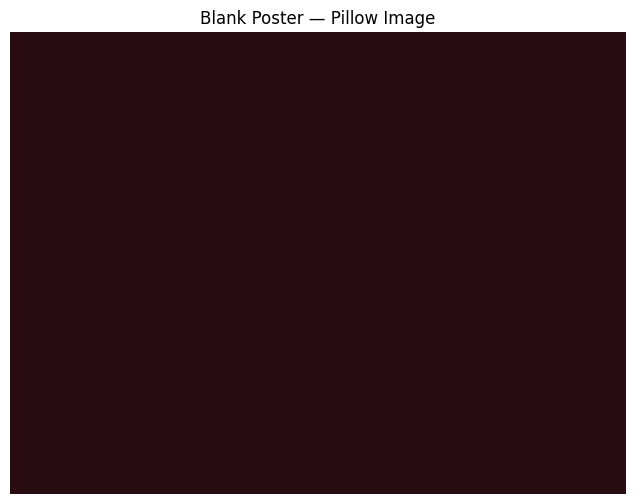

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt

poster = Image.new("RGB", (800, 600), color=(41, 12, 18))

print(f"Type:   {type(poster)}")
print(f"Size:   {poster.size}")
print(f"Mode:   {poster.mode}")
print(f"Width:  {poster.width}")
print(f"Height: {poster.height}")

plt.figure(figsize=(8, 6))
plt.imshow(poster)
plt.title("Blank Poster — Pillow Image")
plt.axis("off")
plt.show()

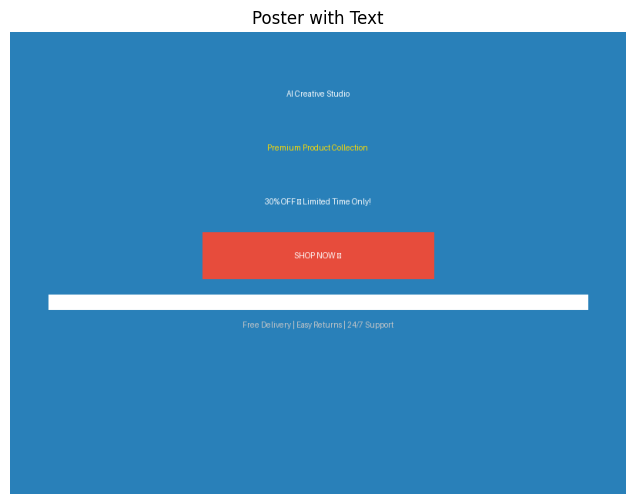

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

poster = Image.new("RGB", (800, 600), color=(41, 128, 185))
draw   = ImageDraw.Draw(poster)

draw.text((400, 80),
          "AI Creative Studio",
          fill=(255, 255, 255),
          anchor="mm")

draw.text((400, 150),
          "Premium Product Collection",
          fill=(255, 220, 0),
          anchor="mm")

draw.text((400, 220),
          "30% OFF — Limited Time Only!",
          fill=(255, 255, 255),
          anchor="mm")

draw.rectangle([(250, 260), (550, 320)],
               fill=(231, 76, 60))

draw.text((400, 290),
          "SHOP NOW →",
          fill=(255, 255, 255),
          anchor="mm")

draw.line([(50, 350), (750, 350)],
          fill=(255, 255, 255),
          width=20)

draw.text((400, 380),
          "Free Delivery | Easy Returns | 24/7 Support",
          fill=(200, 200, 200),
          anchor="mm")

plt.figure(figsize=(8, 6))
plt.imshow(poster)
plt.title("Poster with Text")
plt.axis("off")
plt.show()

--2026-09-18 09:37:22--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-09-18 09:37:22--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.1.129, 216.150.16.129
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.1.129|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-09-18 09:37:23--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Loca

/tmp/ipykernel_2073/1228191042.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  product_pil = Image.fromarray(rgba, "RGBA")


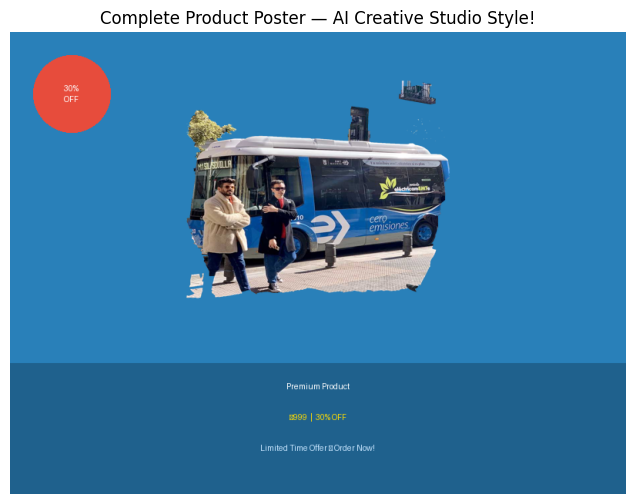

Poster saved!
Size: (800, 600)
Mode: RGB


In [10]:
!wget -O test_image.jpg "https://ultralytics.com/images/bus.jpg"
sample_image = "test_image.jpg"
from PIL import Image, ImageDraw
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr    = cv2.imread("test_image.jpg")
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w       = img_rgb.shape[:2]

mask       = np.zeros((h, w), np.uint8)
bgd_model  = np.zeros((1, 65), np.float64)
fgd_model  = np.zeros((1, 65), np.float64)
rect       = (10, 10, w-20, h-20)
cv2.grabCut(img_bgr, mask, rect,
            bgd_model, fgd_model,
            10, cv2.GC_INIT_WITH_RECT)
final_mask = np.where(
    (mask == 2) | (mask == 0), 0, 1
).astype("uint8")

rgba        = np.dstack([img_rgb,
                         final_mask * 255]).astype(np.uint8)
product_pil = Image.fromarray(rgba, "RGBA")
product_pil = product_pil.resize((350, 350))

poster = Image.new("RGB", (800, 600), (41, 128, 185))

bg_layer = Image.new("RGBA", poster.size,
                     (41, 128, 185, 255))
bg_layer.paste(product_pil,
               (225, 60),
               product_pil)
poster   = bg_layer.convert("RGB")

draw = ImageDraw.Draw(poster)

draw.rectangle([(0, 430), (800, 600)],
               fill=(31, 97, 141))

draw.text((400, 460),
          "Premium Product",
          fill=(255, 255, 255),
          anchor="mm")

draw.text((400, 500),
          "₹999  |  30% OFF",
          fill=(255, 220, 0),
          anchor="mm")

draw.text((400, 540),
          "Limited Time Offer — Order Now!",
          fill=(200, 230, 255),
          anchor="mm")

draw.ellipse([(30, 30), (130, 130)],
             fill=(231, 76, 60))
draw.text((80, 80),
          "30%\nOFF",
          fill=(255, 255, 255),
          anchor="mm")

poster.save("/content/final_poster.jpg", quality=95)

plt.figure(figsize=(8, 6))
plt.imshow(poster)
plt.title("Complete Product Poster — AI Creative Studio Style!")
plt.axis("off")
plt.show()

print("Poster saved!")
print(f"Size: {poster.size}")
print(f"Mode: {poster.mode}")

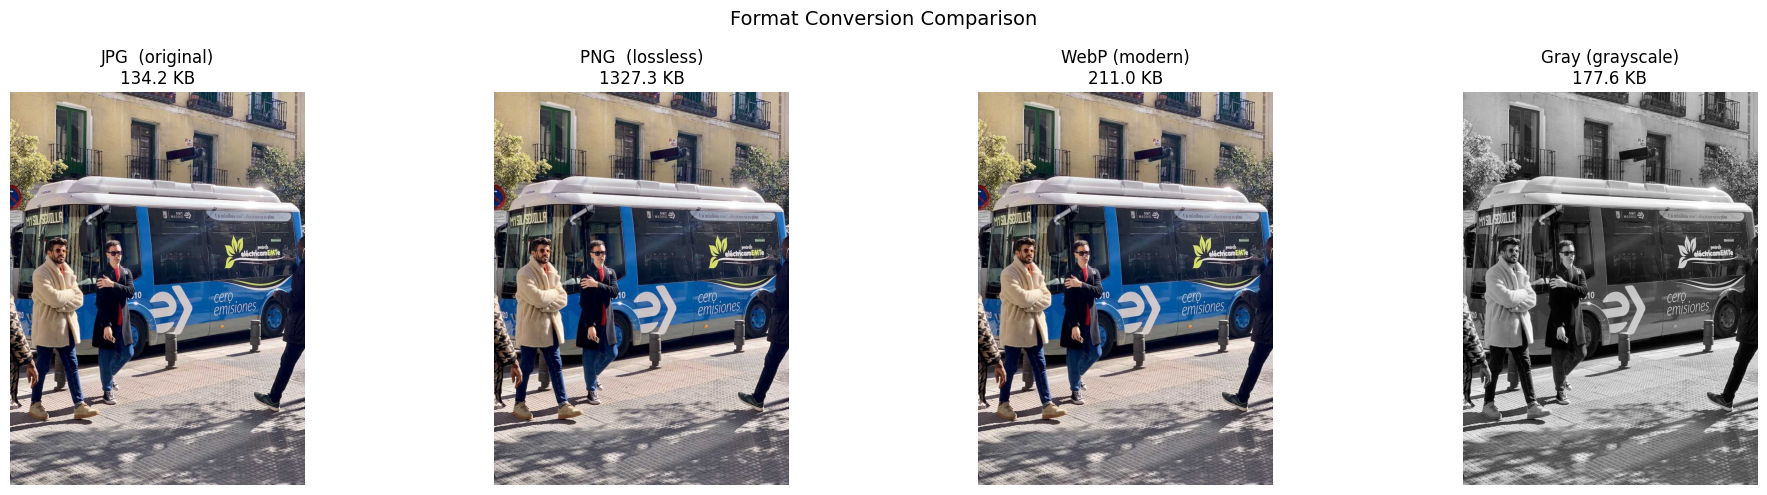

Format sizes:
  JPG  (original) → 134.2 KB
  PNG  (lossless) → 1327.3 KB
  WebP (modern) → 211.0 KB
  Gray (grayscale) → 177.6 KB


In [11]:
from PIL import Image
import os

img = Image.open("test_image.jpg")

img.save("/content/output.png")
img.save("/content/output.webp", quality=85)

img_gray = img.convert("L")
img_gray.save("/content/output_gray.jpg")

img_rgba = img.convert("RGBA")
img_rgba.save("/content/output_transparent.png")

formats = {
    "JPG  (original)":  "test_image.jpg",
    "PNG  (lossless)":  "/content/output.png",
    "WebP (modern)":    "/content/output.webp",
    "Gray (grayscale)": "/content/output_gray.jpg"
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (label, path) in enumerate(formats.items()):
    img_show = Image.open(path)
    if img_show.mode == "L":
        axes[i].imshow(img_show, cmap="gray")
    else:
        axes[i].imshow(img_show)
    size_kb = os.path.getsize(path) / 1024
    axes[i].set_title(f"{label}\n{size_kb:.1f} KB")
    axes[i].axis("off")

plt.suptitle("Format Conversion Comparison", fontsize=14)
plt.tight_layout()
plt.show()

print("Format sizes:")
for label, path in formats.items():
    size = os.path.getsize(path) / 1024
    print(f"  {label} → {size:.1f} KB")